# Занятие 4. Объектно-ориентированное программирование. Модель памяти python

К этому моменту вы уже так или иначе умеете писать примитивный код на python. Прочитав название лекции, вероятно, вы зададитесь вопросом, зачем вам нужна теория по ООП, если вы хотите заниматься data science, а не backend-разработкой. Да, 90% кода в DS $-$ это действительно скрипты и функции. Но есть "но". Те 10%, которые выходят за рамки скриптов, обычно и становятся причиной самых дурацких ошибок, на отладку которых уходят дни.

In [1]:
import pandas as pd

df = pd.DataFrame({'значение' : [1, 2, 3, 4, 5]})
print(f"Оригинал:")
df

Оригинал:


,значение
0,1
1,2
2,3
3,4
4,5


In [2]:
# какая-то очень полезная функция для обработки данных
def normalize_data(data):
    data = (data - data.mean()) / data.std()
    return data

In [3]:
# применение функции
df['нормализованное'] = normalize_data(df['значение'])
print("После функции:")
df

После функции:


,значение,нормализованное
0,1,-1.264911
1,2,-0.632456
2,3,0.000000
3,4,0.632456
4,5,1.264911


Пока мы находимся в jupyter notebook, всё работает успешно. А тепепрь представьте, что мы не просто создаём новую колонку, а *изменяем* исходную. Допустим, мы рещили сэкономить память и написали функцию с параметром `inplace=True`, как это любят делать в pandas.

In [4]:
def bad_normalize(data, inplace=False):
    if inplace:
        data = (data - data.mean()) / data.std() # что в этой строке плохого?
        return data
    else:
        (data - data.mean()) / data.std()

In [5]:
# пытаемся изменить исходный столбец
bad_normalize(df['значение'], inplace=True)

print("А что с оригиналом?")
df

А что с оригиналом?


,значение,нормализованное
0,1,-1.264911
1,2,-0.632456
2,3,0.000000
3,4,0.632456
4,5,1.264911


Ничего не изменилось. Или изменилось? А если изменилось, то где? Почему? Мы только что создали идеальную почву для бага, который проявит себя через три недели, когда модель начнёт выдавать ерунду, а мы будем винить во всём данные.

Так вот, вся лекция $-$ про то, чтобы таких сюрпризов больше не было.

В этом занятии мы разберёмся, что на самом деле происходит, когда ты пишешь `a = b`. Почему меняется (или не меняется) исходный DataFrame, когда ты передаёшь его в свою функцию. И как подружить объектно-ориентированное мышление с задачами Data Science.

**Зачем это нужно?**

- Чтобы читать чужой код. Открываете любой трансформер из sklearn или класс модели из PyTorch (`nn.Module`), а там $-$ сплошные классы, методы `fit`, `transform`, магия `self`. Без понимания ООП ты будешь видеть там просто набор непонятных слов.
- Чтобы писать надёжный код. Когда вы начнёте строить сложные пайплайны (конвейеры обработки данных) или писать кастомные слои для нейросетей, без контроля над памятью и ссылками вы утонете в багах.

## От процедурного подхода к объектному

Начнём с задачи, которая возникает у любого data scientist на второй день работы. У нас есть данные. Их нужно нормализовать $-$ привести к среднему 0 и стандартному отклонению 1. Как это сделать? Можно взять готовый `StandardScaler` из `sklearn`, но мы сейчас должны сосредоточиться на понимании, а не на готовых решениях.

### Процедурный подход: две функции

Нашими данными будет синтетический (в том плане, что искусственный) датасет с зарплатами:

Первые 5 значений: [ 8371.42114929 67363.24033401 15279.74535915 38150.52797503
   734.11103583]
Среднее: 49747, Стандартное отклонение: 49595


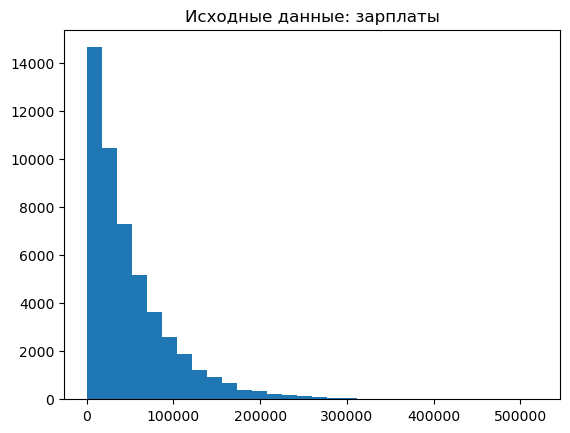

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# набор данных с сильным разбросом
np.random.seed(12)
salaries = np.random.exponential(scale=50_000, size=50_000)
print(f"Первые 5 значений: {salaries[:5]}")
print(f"Среднее: {salaries.mean():.0f}, Стандартное отклонение: {salaries.std():.0f}")

# посмотрим, как распределись значения
plt.hist(salaries, bins=30)
plt.title("Исходные данные: зарплаты")
plt.show(); # ; чтобы не выводилась системная информация

Типичная картина $-$ логарифмическое распределение, большой разброс: редкие, но очень большие значения будут "оттягивать" внимание простых моделей на себя, из-за чего модель будет сильно ошибаться. Поэтому такие данные необходимо привести к единой шкале, то есть **нормализовать**.

Сделаем две функции. Первая $-$ `fit_normalize` $-$ вычислит параметры нормализации.

In [7]:
def fit_normalize(data):
    mean = np.mean(data)
    std = np.std(data)
    return mean, std

# применяем
mean, std = fit_normalize(salaries)
print(f"Вычисленные параметры: mean={mean:.0f}, std={std:.0f}") # литерал f указывает, что строка форматируема

Вычисленные параметры: mean=49747, std=49595


Вторая функция $-$ `transform_normalize` $-$ применяет нормализацию с использованием заранее вычисленных параметров.

После нормализации: среднее=-0.00, std=1.00


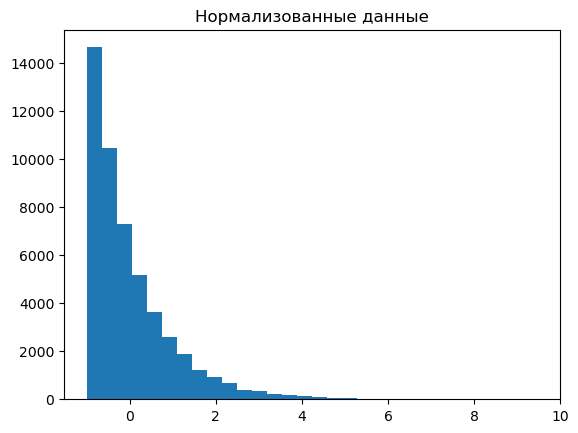

In [8]:
def transform_normalize(data, mean, std):
    return (data - mean) / std

# нормализуем данные
salaries_norm = transform_normalize(salaries, mean, std)

print(f"После нормализации: среднее={salaries_norm.mean():.2f}, std={salaries_norm.std():.2f}")
plt.hist(salaries_norm, bins=30)
plt.title("Нормализованные данные")
plt.show()

Пока всё работает, но что происходит в реальном проекте?

### Проблема №1: Потеря параметров

Вы обучили модель, сохранили её. Через неделю приходят новые данные, на которых нужно выработать новые прогнозы модели. Вопрос: где среднее и стандартное отклонение, которые вы использовали для нормализации?

Если не сохранили их специально $-$ вы не сможете правильно обработать новые данные.
Приходится городить "костыли": возвращать параметры из функций, пакуя их в словари.

In [9]:
def fit_normalize_with_return(data):
    """Костыль: возвращаем параметры"""
    mean = np.mean(data)
    std = np.std(data)
    return mean, std, {'mean': mean, 'std': std}  # зачем-то три раза одно и то же

### Проблема №2: Размывание логики

Представьте, что у нас не один трансформер, а три: нормализация, обработка **выбросов** (аномальные значения в данных), генерация других признаков. Исходный код превращается в кашу:

In [10]:
def transform_poly(data, params):
    pass

def fit_poly(data):
    pass

def fit_outliers(data):
    return min(data), max(data)

def transform_outliers(data, low, up):
    pass


train = salaries[:40_000]
test = salaries[40_000:]

# шаг 1: нормализация
mean, std = fit_normalize(train)
train_norm = transform_normalize(train, mean, std)
test_norm = transform_normalize(test, mean, std)

# шаг 2: обработка выбросов (нужны свои параметры)
lower, upper = fit_outliers(train_norm)
train_clean = transform_outliers(train_norm, lower, upper)
test_clean = transform_outliers(test_norm, lower, upper)

# шаг 3: полиномиальные признаки (опять параметры)
poly_params = fit_poly(train_clean)
train_poly = transform_poly(train_clean, poly_params)
test_poly = transform_poly(test_clean, poly_params)

# и теперь нужно тащить через весь код ТРИ набора параметров!
all_params = {
    'norm': {'mean': mean, 'std': std},
    'outlier': {'lower': lower, 'upper': upper},
    'poly': poly_params
}

Недостатки такого кода видны сразу.
- параметры размазаны по всему коду;
- нарушена целостность;
- код не расширяем (хочешь добавить новый шаг, перепиши всё).

### Альтернатива: объектный взгляд

А теперь взглянем на ситуацию иначе. Что такое нормализатор? Это **объект**, у которого есть:

- **состояние** (данные) $-$ вычисленные среднее и стандартное отклонение;
- **поведение** (методы) $-$ `fit` (вычислить параметры) и `transform` (применить нормализацию).

Как это будет выглядеть:

In [11]:
class Normalizer:
    def __init__(self):
        self.mean = None
        self.std = None
        print("Создан объект-нормализатор")

    def fit(self, data):
        self.mean = np.mean(data)
        self.std = np.std(data)
        print(f"Обучен: mean={self.mean:.0f}, std={self.std:.0f}")
        return self  # возвращаем себя для цепочек вызовов

    def transform(self, data):
        if self.mean is None:
            raise ValueError("Сначала нужно вызвать fit()!")
        return (data - self.mean) / self.std
    
    def fit_transform(self, data):
        return self.fit(data).transform(data)

Картина становится проще:

In [12]:
# cоздаем объект
normalizer = Normalizer()

# обучаем на train — параметры сохраняются ВНУТРИ объекта
normalizer.fit(train)

# нормализуем train и test одним методом
train_norm = normalizer.transform(train)
test_norm = normalizer.transform(test)  # Автоматически используются параметры из fit!

# можно даже сделать цепочку вызовов
train_norm2 = Normalizer().fit_transform(train)

Создан объект-нормализатор
Обучен: mean=49945, std=49800
Создан объект-нормализатор
Обучен: mean=49945, std=49800


Чувствуете разницу? 
- Параметры не болтаются отдельно, мы не обязаны держать их постоянно в голове и отслеживать, чтобы они в какой-то части программы не изменились, потому что они живут внутри объекта;
- Логика собрана в одном месте: класс описывает всё, что нужно для нормализации;
- Код читается как предложение: создай нормализатор -> обучи на train -> обучи на test;
- Расширяемость: хочешь добавить новый метод нормализации $-$ создай новый класс, не ломая старый код.

## Классы и объекты

Разберём анатомию классов. Что происходит внутри, когда мы пишем `class Normalizer`?

### Класс - это свиток с заклинанием

Самая простая аналогия: это свиток с заклинанием, в котором описано, как создать в реальном мире овечку, а объект (экземпляр) $-$ это конкретная овечка, наколдованная по этому заклинанию.

Заклинание одно, а овечек можно наколдовать много. И каждая овечка будет особенной по-своему (это её персональные данные (ха-ха!)), но структура их будет одинаковой $-$ овечной ((ха-ха!)$^2$).

Создадим наш первый класс, максимально простой:

In [13]:
class Sheep:
    pass

sheep_1 = Sheep()
sheep_2 = Sheep()

print(f"sheep_1: {sheep_1}")
print(f"sheep_2: {sheep_2}")
print(f"Тип obj1: {type(sheep_1)}")
print(f"sheep_1 это sheep_2? {sheep_1 is sheep_2}")  # это разные объекты!

sheep_1: <__main__.Sheep object at 0x7faf42d3f510>
sheep_2: <__main__.Sheep object at 0x7faf42d3d350>
Тип obj1: <class '__main__.Sheep'>
sheep_1 это sheep_2? False


Как вы можете видеть, у нас два разных объекта, хотя созданы по одному "заклинанию". У каждого своя ячейка памяти.

### Конструктор `__init__`: волшебная палочка

Теперь сделаем полезный класс. В Data Science нам нужно, чтобы объект при рождении уже имел какую-то начальную структуру, Например, место для хранения среднего и стандартного отклонения.

Для этого существует специальный метод `__init__` (инициализатор, он же конструктор).

In [14]:
class Normalizer:
    """Класс для нормализации данных"""

    def __init__(self):
        """Этот метод вызывается автоматически при создании объекта"""
        print("Вызван __init__! Создаю новый объект Normalizer")
        self.mean = None # здесь будем хранить среднее 
        self.std = None # здесь будем хранить стандартное отклонение
        self.is_fitted = False # флаг: обучен ли уже нормализатор

In [15]:
# создаём объект
norm = Normalizer()
print(f"Среднее пока: {norm.mean}")
print(f"Обучен? {norm.is_fitted}")

Вызван __init__! Создаю новый объект Normalizer
Среднее пока: None
Обучен? False


Обратите внимание: `__init__` вызвался сам, без нашего явного вызова. Это магия python: при создании объекта `Normalizer()` автоматически запускается `__init__`.

В ООП python есть очень много разных магических методов (да, они так и называются, dunder or magic methods). Как правило, имена этих методов обрамляются двойным подчёркиванием.

### Тайна `self`: имя конкретной овечки

А теперь самый важный вопрос: что такое `self`?

Проведём эксперимент. Добавим в класс метод, который показывает свой `id`:

In [16]:
class Sheep:
    def __init__(self):
        print(f"id объекта в __init__: {id(self)}")

    def who_am_i(self):
        print(f"id объекта в методе: {id(self)}")
        return self

In [17]:
shon = Sheep()
print(f"id самого объекта: {id(shon)}")

# вызываем метод
shon.who_am_i()

id объекта в __init__: 140390717199376
id самого объекта: 140390717199376
id объекта в методе: 140390717199376


Как видите, все id совпадают! `self` $-$ это и есть сам объект, просто внутри класса (внутри заклинания) мы называем его `self`, а снаружи `shon`.

Можно провести аналогию с зеркалом заднего вида. Когда сидите в машине (внутри метода), вы видите себя в зеркале $-$ это `self`. А когда вы стоите снаружи машины и смотрите на неё $-$ это переменная `shon`.

Если совсем точно: `self` $-$ это ссылка на конкретный экземпляр класса, которая автоматически передаётся в каждый метод при вызове. В других языках есть похожее слово: в java и java script есть слово `this`, которое аналогично по своему принципу.

### Добавляем методы: наделяем объект поведением

Пришло время добавить в наш нормализатор методы `fit` и `transform`. Обратите внимание, как `self` используется для хранения состояния между вызовами методов.

In [18]:
class Normalizer:
    """Класс для нормализации данных"""
    
    def __init__(self):
        print("Создание нового нормализатора...")
        self.mean = None
        self.std = None
        self.is_fitted = False
    
    def fit(self, data):
        """Вычисляет среднее и стандартное отклонение на обучающих данных"""
        print(f"Вызван fit для объекта с id: {id(self)}")
        
        self.mean = np.mean(data)
        self.std = np.std(data)
        self.is_fitted = True
        
        print(f"  Вычислено среднее: {self.mean:.2f}")
        print(f"  Вычислено std: {self.std:.2f}")
        
        # важно! возвращаем self, чтобы можно было делать цепочки вызовов
        return self
    
    def transform(self, data):
        """Применяет нормализацию, используя сохраненные параметры"""
        print(f"Вызван transform для объекта с id: {id(self)}")
        
        if not self.is_fitted:
            raise ValueError("Сначала нужно вызвать fit()!")
        
        result = (data - self.mean) / self.std
        print(f"  Использую среднее={self.mean:.2f}, std={self.std:.2f}")
        return result

In [19]:
norm = Normalizer()           # cоздание объекта
norm.fit(train)               # обучение
transformed = norm.transform(test)  # применение

print(f"Результат: {transformed}")

Создание нового нормализатора...
Вызван fit для объекта с id: 140390855079056
  Вычислено среднее: 49944.78
  Вычислено std: 49799.95
Вызван transform для объекта с id: 140390855079056
  Использую среднее=49944.78, std=49799.95
Результат: [-0.66976981 -0.49166564  2.23384449 ... -0.57043571  3.15811969
 -0.65112956]


### Несколько объектов - несколько состояний

Самое интересное начинается, когда мы создаём несколько объектов одного класса. У каждого будет своё собственное состояние.

In [20]:
# создаем два разных нормализатора
norm1 = Normalizer()
norm2 = Normalizer()

# обучаем на разных данных
data1 = np.array([1, 2, 3, 4, 5])
data2 = np.array([100, 200, 300, 400, 500])

norm1.fit(data1)
norm2.fit(data2)

print(f"norm1.mean: {norm1.mean}")
print(f"norm2.mean: {norm2.mean}")

# применяем к одним и тем же тестовым данным
test_data = np.array([3, 30, 300])
print(f"norm1.transform(test_data): {norm1.transform(test_data)}")
print(f"norm2.transform(test_data): {norm2.transform(test_data)}")

Создание нового нормализатора...
Создание нового нормализатора...
Вызван fit для объекта с id: 140390716856912
  Вычислено среднее: 3.00
  Вычислено std: 1.41
Вызван fit для объекта с id: 140390716853392
  Вычислено среднее: 300.00
  Вычислено std: 141.42
norm1.mean: 3.0
norm2.mean: 300.0
Вызван transform для объекта с id: 140390716856912
  Использую среднее=3.00, std=1.41
norm1.transform(test_data): [  0.          19.09188309 210.01071401]
Вызван transform для объекта с id: 140390716853392
  Использую среднее=300.00, std=141.42
norm2.transform(test_data): [-2.10010714 -1.90918831  0.        ]


Один и тот же код, одни и те же тестовые данные, но разные результаты, потому что объекты хранят разные параметры. Это ключевое преимущество ООП.

### Атрибуты экземпляра: что можно хранить

В атрибутах (`self.что-то`) можно хранить что угодно: числа, строки, массивы, датафреймы, даже другие объекты.

In [21]:
class DataProcessor:
    def __init__(self, name):
        self.name = name           # строка
        self.data = None           # пока пусто, потом положим массив
        self.stats = {}             # словарь для статистик
        self.history = []           # список для истории операций
        self.scaler = Normalizer()  # ДРУГОЙ ОБЪЕКТ как атрибут!
        
    def load_data(self, data):
        self.data = data
        self.history.append(f"Загружено {len(data)} точек")
        
    def compute_stats(self):
        if self.data is not None:
            self.stats['mean'] = np.mean(self.data)
            self.stats['std'] = np.std(self.data)
            self.history.append("Вычислены статистики")
            
    def show_history(self):
        print(f"История процессора '{self.name}':")
        for event in self.history:
            print(f"  - {event}")

# cоздаем процессор
proc = DataProcessor("Тестовый")
proc.load_data([1, 2, 3, 4, 5])
proc.compute_stats()
proc.show_history()

print(f"Статистики: {proc.stats}")
print(f"Внутри живет нормализатор: {proc.scaler}")

Создание нового нормализатора...
История процессора 'Тестовый':
  - Загружено 5 точек
  - Вычислены статистики
Статистики: {'mean': 3.0, 'std': 1.4142135623730951}
Внутри живет нормализатор: <__main__.Normalizer object at 0x7faf4b5b9150>


Это открывает огромные возможности. Мы можем строить сложные иерархии объектов, где один объект содержит другие.

Однако есть ещё один тип атрибутов $-$ **атрибуты класса**. Они общие для всех объектов. Атрибуты класса полезны для констант, счётчиков, общих настроек. Но в DS мы чаще работаем с атрибутами экземпляра $-$ именно они хранят параметры модели, обученной на конкретных данных.

In [22]:
class ImportantClass:
    # атрибут КЛАССА (общий для всех)
    species = "DataScience"
    counter = 0
    
    def __init__(self, name):
        # атрибуты ЭКЗЕМПЛЯРА (у каждого свои)
        self.name = name
        ImportantClass.counter += 1  # увеличиваем общий счетчик

obj_a = ImportantClass("A")
obj_b = ImportantClass("B")

print(f"obj_a.species: {obj_a.species}")  # общий
print(f"obj_b.species: {obj_b.species}")  # тот же общий
print(f"obj_a.name: {obj_a.name}")        # свой
print(f"obj_b.name: {obj_b.name}")        # свой
print(f"Всего создано объектов: {ImportantClass.counter}")

obj_a.species: DataScience
obj_b.species: DataScience
obj_a.name: A
obj_b.name: B
Всего создано объектов: 2


## Базовые принципы ООП

В мире ООП постоянно обсуждают три вещи: **инкапсуляцию**, **наследование** и **полиморфизм**. За каждым этим словом стоит простая и полезная идея. Разберём на примерах из жизни data scientist'a.

### Инкапсуляция: всё нужное $-$ внутри, всё лишнее $-$ снаружи

**Инкапсуляция** $-$ это упаковка данных и методов, работающих с этими данными, внутри одного объекта, а также *контроль доступа* к этим данным.

Вспоминаем класс `Normalizer`. В нём есть инкапсуляция: данные (`self.mean`, `self.std`) и методы (`fit`, `transform`) находятся внутри одного класса.

Представим ситуацию. Кто-то (возможно, и вы сами через некоторое время) решит, что он умнее, и напрямую поменяет параметры нормализатора:

In [23]:
import numpy as np

class Normalizer:
    def __init__(self):
        self.mean = None
        self.std = None
        self.is_fitted = False
    
    def fit(self, data):
        self.mean = np.mean(data)
        self.std = np.std(data)
        self.is_fitted = True
        return self
    
    def transform(self, data):
        if not self.is_fitted:
            raise ValueError("Сначала нужно вызвать fit()!")
        return (data - self.mean) / self.std



train = np.array([10, 20, 30, 40, 50])
norm = Normalizer()
norm.fit(train)

# здесь всё ещё хорошо
print(f"Правильный transform: {norm.transform(np.array([25]))[0]:.2f}")

# а теперь кто-то подкрутил параметры вручную
norm.mean = 1000  # зачем? Кто знает...
norm.std = 0.1    # опасно!

# модель ломается
print(f"После 'улучшения': {norm.transform(np.array([25]))[0]:.2f}")
# результат: (25 - 1000)/0.1 = -9750! Катастрофа

Правильный transform: -0.35
После 'улучшения': -9750.00


Объект в невалидном состоянии, а мы ничего не можем с этим сделать. Пользователь нашего класса поломал всё изнутри. Но для этого есть решение $-$ **защищённые атрибуты**.

В python нет строгой приватности, как в java или C++. Но есть **соглашение**: если атрибут начинается с подчёркивания, значит, его не следует трогать снаружи.

In [24]:
class SafeNormalizer:
    def __init__(self):
        self._mean = None      # одно подчеркивание — "защищенный"
        self._std = None       # не трогать снаружи!
        self._is_fitted = False
    
    def fit(self, data):
        self._mean = np.mean(data)
        self._std = np.std(data)
        self._is_fitted = True
        return self
    
    def transform(self, data):
        if not self._is_fitted:
            raise ValueError("Сначала нужно вызвать fit()!")
        return (data - self._mean) / self._std
    
    # Добавим метод для безопасного доступа к параметрам
    def get_params(self):
        """Безопасный способ посмотреть параметры"""
        if not self._is_fitted:
            return None
        return {'mean': self._mean, 'std': self._std}

# теперь пользователь видит подчеркивания и понимает: "лезть сюда не стоит"
safe_norm = SafeNormalizer()
safe_norm.fit(train)

# получить параметры можно через специальный метод, который называется геттером
print(f"Параметры: {safe_norm.get_params()}")

# Но если очень хочется, технически можно и сломать
# safe_norm._mean = 1000  # Синтаксис разрешает, но это плохой тон!

Параметры: {'mean': 30.0, 'std': 14.142135623730951}


Где мы видим инкапсуляцию в реальных DS-библиотеках? Везде! например:

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

n_samples = 1000
n_features = 5

feature_1 = np.random.normal(loc=0, scale=1, size=n_samples)
feature_2 = np.random.normal(loc=50, scale=10, size=n_samples)
feature_3 = np.random.uniform(low=-100, high=100, size=n_samples)
feature_4 = np.random.exponential(scale=2, size=n_samples)
feature_5 = np.random.binomial(n=20, p=0.5, size=n_samples)

# cобираем все признаки в матрицу X
X_train = np.column_stack([feature_1, feature_2, feature_3, feature_4, feature_5])

true_coef = np.array([2.5, -1.8, 0.5, 3.2, -0.7])
# линейная комбинация признаков
logits = X_train @ true_coef + np.random.normal(0, 5, size=n_samples)
# вероятности через сигмоиду
probabilities = 1 / (1 + np.exp(-logits))
# бинарные метки (0, 1)
y_train = (probabilities > 0.5).astype(int)


# создаем модели
scaler = StandardScaler()
model = LogisticRegression()

# обучаем
X_train_scaled = scaler.fit_transform(X_train)  # внутри вычисляются scaler.mean_ и scaler.var_
model.fit(X_train_scaled, y_train)

# параметры модели хранятся внутри, мы не можем их случайно испортить
print(f"Коэффициенты модели: {model.coef_[0][:5]}...")  # можно посмотреть
# model.coef_ = [1,2,3]  # но менять напрямую — моветон!

# у модели есть методы для безопасного доступа
print(f"Параметры: {model.get_params()}")

Коэффициенты модели: [ 0.71944323 -1.16720931  0.90238169 -0.34565511 -0.03328368]...
Параметры: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


Смысл инкапсуляции: объект сам отвечает за целостность своего состояния. Мы общаемся с ним через чётко определённые методы, а не копаемся в его внутренностях.

### Наследование: не изобретай велосипед

Второй принцип $-$ наследование. Это механизм, который позволяет создавать новые классы на основе существующих, заимствуя их функциональность.

Зачем это нужно в DS? Представьте, что мы хотим создать семейство нормализаторов: StandardScaler, MinMaxScaler, RobustScaler. У них будет много общего, но разная реализация.

Реализуем базовый класс (родителя):

In [31]:
class BaseScaler:
    """Базовый класс для всех нормализаторов"""
    
    def __init__(self):
        self._is_fitted = False
        print("BaseScaler __init__ вызван")
    
    def fit(self, X):
        """Базовый метод fit — должен быть переопределен в потомках"""
        raise NotImplementedError("Подклассы должны реализовать!")
    
    def transform(self, X):
        """Базовый метод transform"""
        if not self._is_fitted:
            raise ValueError(f"{self.__class__.__name__} не обучен! Сначала вызови fit.")
        return self._transform_implementation(X)
    
    def _transform_implementation(self, X):
        """Внутренний метод, который будут переопределять потомки"""
        raise NotImplementedError
    
    def fit_transform(self, X):
        """Удобный метод: обучиться и применить за один вызов"""
        return self.fit(X).transform(X)

А теперь реализуем классы-потомки, которые заимствуют сигнатуры методов от родительского класса.

In [32]:
class StandardScaler(BaseScaler):
    """Стандартизация: (x - mean) / std"""
    
    def __init__(self):
        # вызываем конструктор родителя!
        super().__init__()
        self.mean_ = None
        self.std_ = None
        print("StandardScaler __init__ вызван")
    
    def fit(self, X):
        print(f"StandardScaler.fit на данных формы {X.shape}")
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self._is_fitted = True
        return self
    
    def _transform_implementation(self, X):
        """Реализуем специфичную для этого класса логику"""
        return (X - self.mean_) / self.std_


class MinMaxScaler(BaseScaler):
    """Масштабирование в диапазон [0, 1]"""
    
    def __init__(self):
        super().__init__()
        self.min_ = None
        self.max_ = None
        print("MinMaxScaler __init__ вызван")
    
    def fit(self, X):
        print(f"MinMaxScaler.fit на данных формы {X.shape}")
        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)
        self._is_fitted = True
        return self
    
    def _transform_implementation(self, X):
        return (X - self.min_) / (self.max_ - self.min_)


class RobustScaler(BaseScaler):
    """Масштабирование на основе медианы и квартилей"""
    
    def __init__(self):
        super().__init__()
        self.median_ = None
        self.iqr_ = None
        print("RobustScaler __init__ вызван")
    
    def fit(self, X):
        print(f"RobustScaler.fit на данных формы {X.shape}")
        self.median_ = np.median(X, axis=0)
        q1 = np.percentile(X, 25, axis=0)
        q3 = np.percentile(X, 75, axis=0)
        self.iqr_ = q3 - q1
        self._is_fitted = True
        return self
    
    def _transform_implementation(self, X):
        return (X - self.median_) / self.iqr_

Посмотрим, что мы получили:

In [33]:
# создаем данные
X = np.random.randn(100, 3) * 10 + 5

# создаем разные нормализаторы
scalers = [
    StandardScaler(),
    MinMaxScaler(),
    RobustScaler()
]

# работаем с ними единообразно!
for scaler in scalers:
    print(f"\n--- {scaler.__class__.__name__} ---")
    X_scaled = scaler.fit_transform(X)
    print(f"Форма результата: {X_scaled.shape}")
    print(f"Среднее (примерно): {np.mean(X_scaled[:, 0]):.3f}")

BaseScaler __init__ вызван
StandardScaler __init__ вызван
BaseScaler __init__ вызван
MinMaxScaler __init__ вызван
BaseScaler __init__ вызван
RobustScaler __init__ вызван

--- StandardScaler ---
StandardScaler.fit на данных формы (100, 3)
Форма результата: (100, 3)
Среднее (примерно): 0.000

--- MinMaxScaler ---
MinMaxScaler.fit на данных формы (100, 3)
Форма результата: (100, 3)
Среднее (примерно): 0.502

--- RobustScaler ---
RobustScaler.fit на данных формы (100, 3)
Форма результата: (100, 3)
Среднее (примерно): -0.052


Обратите внимание:

1. `super().init()` $-$ вызываем конструктор родителя, чтобы установить флаг `_is_fitted`;
2. Каждый класс реализует только то, чем отличается от других;
3. Общая логика (проверка на fitted, метод `fit_transform`) находится в родителе;

Это соответствует известному принципу в разработке, который называется **DRY (Don't Repeat Yourself)**.

В реальных библиотеках наследование также используется:

In [34]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# все трансформеры наследуются от BaseEstimator и TransformerMixin
# это дает им методы get_params(), set_params() и fit_transform()

# а пайплайны используют полиморфизм для работы с любыми трансформерами
pipe = Pipeline([
    ('scaler', StandardScaler()),  # любой объект с fit_transform
    ('more_scaler', RobustScaler()) # работает!
])

BaseScaler __init__ вызван
RobustScaler __init__ вызван


### Полиморфизм: один интерфейс $-$ много реализаций

Третий принцип $-$ полиморфизм. Это слово значит "много форм". В программировании это означает, что объекты разных классов могут иметь **одинаковые методы**, и мы можем вызывать эти методы, не зная точного типа объекта.

Мы уже видели полиморфизм в действии в примере с циклами по разным нормализаторам: 

In [35]:
# полиморфизм в действии
def process_data(scaler, X):
    """Функция принимает ЛЮБОЙ объект с методами fit и transform"""
    print(f"Обработка с помощью {scaler.__class__.__name__}")
    result = scaler.fit_transform(X)
    print(f"Результат: форма {result.shape}")
    return result

# одна функция работает с разными типами объектов!
process_data(StandardScaler(), X)
process_data(MinMaxScaler(), X)
process_data(RobustScaler(), X)

Обработка с помощью StandardScaler
Результат: форма (100, 3)
BaseScaler __init__ вызван
MinMaxScaler __init__ вызван
Обработка с помощью MinMaxScaler
MinMaxScaler.fit на данных формы (100, 3)
Результат: форма (100, 3)
BaseScaler __init__ вызван
RobustScaler __init__ вызван
Обработка с помощью RobustScaler
RobustScaler.fit на данных формы (100, 3)
Результат: форма (100, 3)


array([[-0.18385973, -0.51745848, -0.82874203],
       [ 1.78042345,  0.13665946, -0.53858309],
       [-0.71458896,  0.29959531,  0.49430705],
       [-0.38940621, -1.17851648,  0.25384466],
       [ 0.86961974, -0.32802834, -0.07024162],
       [ 0.03166672,  0.58927461,  1.47196589],
       [ 1.23151137, -0.31986622, -0.45430142],
       [ 0.60373404,  0.601603  , -0.57612744],
       [ 0.13966134,  0.26740975,  0.28114006],
       [ 0.41090176, -0.52634999, -0.82121186],
       [-0.41677812, -0.37133565,  0.78380871],
       [-2.54827865, -1.25632993, -1.67537556],
       [-0.12001339, -0.40158991, -0.16017103],
       [ 0.20846316,  0.94650567, -0.61002105],
       [ 1.02229787,  0.47544993, -0.15939409],
       [-2.99677534,  0.09711076, -0.34188381],
       [ 0.21228445, -0.04418351,  0.02747213],
       [-1.28234357,  0.93325601, -0.50427588],
       [-1.01713781,  0.6043719 ,  0.51966181],
       [ 1.03286385, -1.31559851, -0.03216772],
       [ 0.09649393, -0.72431782,  0.580

В python полиморфизм работает через так называемую **утиную типизацию**. Если объект ходит как утка и крякает как утка $-$ значит, это утка.

Нам не нужно, чтобы объект был потомком определённого класса. Достаточно, чтобы у него были нужные методы.

In [36]:
class CrazyScaler:
    """Сумасшедший нормализатор, который не наследуется от BaseScaler"""
    
    def fit(self, X):
        print("CrazyScaler fit: делаю вид, что учусь")
        return self
    
    def transform(self, X):
        print("CrazyScaler transform: ничего не делаю, просто возвращаю данные")
        return X
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

# но он работает точно так же!
crazy = CrazyScaler()
process_data(crazy, X)  # всё работает!

Обработка с помощью CrazyScaler
CrazyScaler fit: делаю вид, что учусь
CrazyScaler transform: ничего не делаю, просто возвращаю данные
Результат: форма (100, 3)


array([[  3.41951536,   0.21920089,  -3.76136241],
       [ 24.35747567,   6.57572476,  -0.35753069],
       [ -2.23770732,   8.159087  ,  11.75922225],
       [  1.22852578,  -6.20476443,   8.9383769 ],
       [ 14.64891016,   2.06002678,   5.13654623],
       [  5.7168849 ,  10.97410444,  23.2280611 ],
       [ 18.50643572,   2.13934381,   0.6311709 ],
       [ 11.81474433,  11.093908  ,  -0.79796046],
       [  6.86803619,   7.84631725,   9.25857702],
       [  9.75927969,   0.13279588,  -3.67302652],
       [  0.93675928,   1.63917918,  15.15534344],
       [-21.78362742,  -6.96093237, -13.69315368],
       [  4.10007521,   1.34517726,   4.08159136],
       [  7.60141807,  14.44556973,  -1.19556374],
       [ 16.27635818,   9.86798993,   4.09070562],
       [-26.56430567,   6.19140231,   1.9499331 ],
       [  7.64215048,   4.81834655,   6.28281849],
       [ -8.28959617,  14.31681352,   0.04492448],
       [ -5.46267815,  11.12081536,  12.05665694],
       [ 16.3889845 ,  -7.53688

Это и есть полиморфизм в Python $-$ важность имеет поведение, а не происхождение.

## Модель памяти в python

Пришло время заглянуть под капот в Python и понять самую важную для data scientist'a тему $-$ как устроена память.

Почему это так критично именно для DS?

Представьте, что вы работаете с датасетом на 50 гагабайт. Вы пишите `df2 = df1`, думая, что создёте копию, а на самом деле просто создаёте вторую ссылку на те же данные. Через пару преобразований вы случайно портите исходный датафрейм, и всё $-$ придётся переобучать модель заново. Или хуже $-$ модель ушла в прод с испорченными данными.

Или другой сценарий: вы передали огромный массив в функцию, функция его изменила, а вы не ожидали. Память утекла, код упал.

### Всё есть объект

Первый и самый важный принцип Python, который нужно усвоить раз и навсегда: **в python всё является объектом**. Абсолютно всё: числа, строки, списки, функции, классы $-$ всё это объекты.

In [37]:
# даже числа — это объекты
x = 5
print(f"x = {x}")
print(f"Тип x: {type(x)}")
print(f"ID x: {id(x)}")
print(f"Атрибуты числа: {dir(x)[:10]}...")  # У числа есть методы!

print("\n" + "="*50 + "\n")

# cтроки — тоже объекты
s = "hello"
print(f"s = '{s}'")
print(f"Тип s: {type(s)}")
print(f"ID s: {id(s)}")
print(f"Метод upper: {s.upper()}")  # Вызываем метод объекта

print("\n" + "="*50 + "\n")

# функции — объекты
def my_func():
    return 42

print(f"my_func = {my_func}")
print(f"Тип my_func: {type(my_func)}")
print(f"ID my_func: {id(my_func)}")

x = 5
Тип x: <class 'int'>
ID x: 94296400253992
Атрибуты числа: ['__abs__', '__add__', '__and__', '__bool__', '__ceil__', '__class__', '__delattr__', '__dir__', '__divmod__', '__doc__']...


s = 'hello'
Тип s: <class 'str'>
ID s: 140397651085488
Метод upper: HELLO


my_func = <function my_func at 0x7faedaf1f600>
Тип my_func: <class 'function'>
ID my_func: 140388974327296


У каждого объекта в Python ести три характеристики:
- идентификатор (id) $-$ уникальный номер объекта в памяти, сравнивается через оператор `is`;
- тип (type) $-$ определяет, что можно делать с объектом;
- значение (value) $-$ собственно данные.

Самое важное здесь $-$ понять разницу между *переменной* и *объектом*:

In [38]:
# переменная - это просто имя (ярлык), привязанное к объекту
a = [1, 2, 3]  # создали объект-список и привязали к нему имя 'a'
b = a          # привязали имя 'b' к ТОМУ ЖЕ объекту
c = [1, 2, 3]  # создали НОВЫЙ объект-список

print(f"a id: {id(a)}")
print(f"b id: {id(b)}")
print(f"c id: {id(c)}")
print(f"a is b: {a is b}")  # True - это один объект
print(f"a is c: {a is c}")  # False - разные объекты
print(f"a == c: {a == c}")  # True - но значения одинаковые

a id: 140388971381120
b id: 140388971381120
c id: 140388971384576
a is b: True
a is c: False
a == c: True


Можно представлять себе примерно так: объекты $-$ воздушные шарики, которые живут сами по себе, а переменные $-$ это ниточки, за которые вы их держите. Один шарик можно держать за несколько ниточек.

### Изменяемые (mutable) и неизменяемые (immutable) типы

Все типы в python деляться на две категории: изменяемые и неизменяемые.

Неизменяемые объекты нельзя изменить после создания. Любое изменение создаёт новый объект.

In [39]:
# пример с int (неизменяемый)
x = 10
print(f"Создали x = 10, id: {id(x)}")

x = x + 5
print(f"После x = x + 5, id: {id(x)}")  # id изменился!

# можно проверить через is
y = 10
z = 10
print(f"y is z: {y is z}")  # python кэширует маленькие целые числа, но не надейся на это!

Создали x = 10, id: 94296400254152
После x = x + 5, id: 94296400254312
y is z: True


К неизменяемым типам относятся:
- `int`, `float`, `complex` $-$ числа;
- `str` $-$ строки;
- `tuple` $-$ кортежи;
- `frozenset` $-$ неизменяемые множества;
- `bytes` $-$ байтовые строки.

А вот изменяемые объекты можно менять, не создавая новых. Изменения происходят in-place (на месте).

In [40]:
# cписок — изменяемый тип
lst = [1, 2, 3]
print(f"Создали список {lst}, id: {id(lst)}")

lst.append(4)
print(f"После append(4): {lst}, id: {id(lst)}")  # id тот же!

lst[0] = 100
print(f"После lst[0] = 100: {lst}, id: {id(lst)}")  # id всё еще тот же!

# удаление элемента
lst.pop()
print(f"После pop(): {lst}, id: {id(lst)}")  # id не изменился!

Создали список [1, 2, 3], id: 140388963417280
После append(4): [1, 2, 3, 4], id: 140388963417280
После lst[0] = 100: [100, 2, 3, 4], id: 140388963417280
После pop(): [100, 2, 3], id: 140388963417280


К изменяемым типам относятся:

- `list` $-$ списки;
- `dict` $-$ словари;
- `set` $-$ множества;
- `pandas.DataFrame`, `pandas.Series`;
- `numpy.ndarray`;
- пользовательские классы.

А теперь смотрите, ради чего мы всё это затеяли. Вот где подстерегает опасность:

In [41]:
import numpy as np
import pandas as pd

# === NUMPY ===
arr = np.array([1, 2, 3, 4, 5])
print(f"Исходный массив: {arr}, id: {id(arr)}")

# изменяем элемент
arr[0] = 999
print(f"После arr[0] = 999: {arr}, id: {id(arr)}")  # id тот же! массив изменился

# арифметические операции обычно создают копию
arr2 = arr * 2
print(f"arr * 2: {arr2}, id: {id(arr2)}")  # новый id

# но есть in-place операции!
arr *= 2
print(f"После arr *= 2: {arr}, id: {id(arr)}")  # id тот же! оригинал изменился!

# === PANDAS ===
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
print(f"\nИсходный DataFrame:")
print(df)
print(f"ID df: {id(df)}")

# изменяем по индексу
df.loc[0, 'A'] = 999
print(f"\nПосле df.loc[0, 'A'] = 999:")
print(df)
print(f"ID df: {id(df)}")  # тот же!

# методы с inplace=True
df.drop(1, inplace=True)
print(f"\nПосле drop(inplace=True):")
print(df)
print(f"ID df: {id(df)}")  # Тот же!

# но не все методы работают inplace!
df2 = df.reset_index()  # по умолчанию создает копию
print(f"\ndf.reset_index() создает новый объект:")
print(f"ID нового df2: {id(df2)}")
print(f"ID исходного df: {id(df)}")  # старый не изменился

Исходный массив: [1 2 3 4 5], id: 140388962511696
После arr[0] = 999: [999   2   3   4   5], id: 140388962511696
arr * 2: [1998    4    6    8   10], id: 140388962515056
После arr *= 2: [1998    4    6    8   10], id: 140388962511696

Исходный DataFrame:
   A  B
0  1  4
1  2  5
2  3  6
ID df: 140388961029520

После df.loc[0, 'A'] = 999:
     A  B
0  999  4
1    2  5
2    3  6
ID df: 140388961029520

После drop(inplace=True):
     A  B
0  999  4
2    3  6
ID df: 140388961029520

df.reset_index() создает новый объект:
ID нового df2: 140390854258512
ID исходного df: 140388961029520


Если вы поняли, что одни объекты можно менять, а другие $-$ нет, и что переменные $-$ это просто ссылки, пришло время разобраться, как правильно создавать копии.

Необходимое замечание: присваивание (=) **не создаёт копию**!

In [42]:
# присваивание создает новую ссылку на ТОТ ЖЕ объект
list1 = [1, 2, 3, [4, 5]]
list2 = list1  # просто новая ссылка

print(f"list1 id: {id(list1)}")
print(f"list2 id: {id(list2)}")
print(f"list1 is list2: {list1 is list2}")  # True — один объект

# изменяем через list2
list2.append(6)
print(f"list1 после изменения list2: {list1}")  # list1 тоже изменился!

list1 id: 140388962666240
list2 id: 140388962666240
list1 is list2: True
list1 после изменения list2: [1, 2, 3, [4, 5], 6]


Есть несколько способов создать копию объекта в python. И один из них $-$ это поверхнотная копия.

Поверхностная копия создёт новый контейнер, но вложенные объекты всё ещё разделяются.

In [43]:
import copy

list1 = [1, 2, 3, [4, 5]]
list_shallow = copy.copy(list1)  # или list1.copy(), или list1[:]

print(f"list1 id: {id(list1)}")
print(f"list_shallow id: {id(list_shallow)}")  # разные id!
print(f"list1 is list_shallow: {list1 is list_shallow}")  # False

# проверяем вложенный список
print(f"ID вложенного списка в list1: {id(list1[3])}")
print(f"ID вложенного списка в list_shallow: {id(list_shallow[3])}")
print(f"Вложенные списки один объект? {list1[3] is list_shallow[3]}")  # True!

# это приводит к проблемам
list_shallow[3].append(6)  # меняем вложенный список в копии
print(f"list1 после изменения копии: {list1}")  # оригинал тоже изменился!

list1 id: 140388962669760
list_shallow id: 140388961026304
list1 is list_shallow: False
ID вложенного списка в list1: 140388971390016
ID вложенного списка в list_shallow: 140388971390016
Вложенные списки один объект? True
list1 после изменения копии: [1, 2, 3, [4, 5, 6]]


Чтобы создать полностью независимую копию объекта со всеми вложенными объектами, необходимо использовать глубокое копирование.

In [44]:
list1 = [1, 2, 3, [4, 5]]
list_deep = copy.deepcopy(list1)

print(f"ID вложенного списка в list1: {id(list1[3])}")
print(f"ID вложенного списка в list_deep: {id(list_deep[3])}")
print(f"Вложенные списки один объект? {list1[3] is list_deep[3]}")  # False!

# теперь изменения в копии не влияют на оригинал
list_deep[3].append(6)
print(f"list1 после изменения глубокой копии: {list1}")  # не изменился!
print(f"list_deep: {list_deep}")

ID вложенного списка в list1: 140388971395712
ID вложенного списка в list_deep: 140388962668736
Вложенные списки один объект? False
list1 после изменения глубокой копии: [1, 2, 3, [4, 5]]
list_deep: [1, 2, 3, [4, 5, 6]]


Для pandas и numpy:

In [45]:
# === NUMPY ===
arr = np.array([1, 2, 3, 4, 5])
arr_view = arr[:2]      # cоздает VIEW (представление), не копию!
arr_copy = arr.copy()   # cоздает ПОЛНУЮ копию

print(f"Исходный массив: {arr}")
print(f"view (срез): {arr_view}")
print(f"copy: {arr_copy}")

# Изменяем исходный массив
arr[0] = 999
print(f"\nПосле изменения исходного:")
print(f"Исходный: {arr}")
print(f"view: {arr_view}")  # изменился! потому что это view
print(f"copy: {arr_copy}")  # не изменился!

# === PANDAS ===
df = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
df_view = df[:2]           # создает view (предупреждение!)
df_copy = df.copy()        # создает полную копию

df.loc[0, 'A'] = 999

print(f"\nИсходный df после изменения:")
print(df)
print(f"\nview (срез):")
print(df_view)  # изменился!
print(f"\ncopy:")
print(df_copy)  # не изменился!

Исходный массив: [1 2 3 4 5]
view (срез): [1 2]
copy: [1 2 3 4 5]

После изменения исходного:
Исходный: [999   2   3   4   5]
view: [999   2]
copy: [1 2 3 4 5]

Исходный df после изменения:
     A  B
0  999  4
1    2  5
2    3  6

view (срез):
     A  B
0  999  4
1    2  5

copy:
   A  B
0  1  4
1  2  5
2  3  6


### Передача аргументов в функции

Теперь соберём всё вместе и посмотрим, как аргументы передаются в функции.

В python используется механизм, который называется **передача по ссылке на объект** (call by object reference). Звучит страшно, но на самом деле просто:
- если в функцию передан **изменяемый** объект, функция может его изменить;
- если передан **неизменяемый** $-$ не может.

In [46]:
def demonstrate_mutation(immutable_int, mutable_list, mutable_df):
    """Функция, которая пытается изменить аргументы"""
    print("Внутри функции ДО изменений:")
    print(f"  immutable_int = {immutable_int}, id: {id(immutable_int)}")
    print(f"  mutable_list = {mutable_list}, id: {id(mutable_list)}")
    print(f"  mutable_df:\n  {mutable_df}")
    
    # Пытаемся изменить
    immutable_int += 10  # cоздает новый объект
    mutable_list.append(999)  # изменяет существующий
    mutable_df.loc[0, 'A'] = 999  # изменяет существующий
    
    print("\nВнутри функции ПОСЛЕ изменений:")
    print(f"  immutable_int = {immutable_int}, id: {id(immutable_int)}")
    print(f"  mutable_list = {mutable_list}, id: {id(mutable_list)}")
    print(f"  mutable_df:\n  {mutable_df}")


In [47]:
# создаем объекты
x = 5
lst = [1, 2, 3]
df = pd.DataFrame({'A': [1, 2, 3]})

print("ДО вызова функции:")
print(f"x = {x}, id: {id(x)}")
print(f"lst = {lst}, id: {id(lst)}")
print(f"df:\n{df}\n")

print("="*50)
demonstrate_mutation(x, lst, df)
print("="*50)

print("\nПОСЛЕ вызова функции:")
print(f"x = {x}, id: {id(x)}")  # не изменилось!
print(f"lst = {lst}, id: {id(lst)}")  # ИЗМЕНИЛОСЬ и id тот же!
print(f"df:\n{df}")  # ИЗМЕНИЛОСЬ!

ДО вызова функции:
x = 5, id: 94296400253992
lst = [1, 2, 3], id: 140390854753024
df:
   A
0  1
1  2
2  3

Внутри функции ДО изменений:
  immutable_int = 5, id: 94296400253992
  mutable_list = [1, 2, 3], id: 140390854753024
  mutable_df:
     A
0  1
1  2
2  3

Внутри функции ПОСЛЕ изменений:
  immutable_int = 15, id: 94296400254312
  mutable_list = [1, 2, 3, 999], id: 140390854753024
  mutable_df:
       A
0  999
1    2
2    3

ПОСЛЕ вызова функции:
x = 5, id: 94296400253992
lst = [1, 2, 3, 999], id: 140390854753024
df:
     A
0  999
1    2
2    3
